# Büchi Automata & Kripke Models — Graphviz Visualization

High-quality diagrams using **Graphviz** (DOT language). Graphviz produces publication-quality output with excellent self-loop handling and hierarchical layout.

In [1]:
%matplotlib inline
import os, sys
import IPython.display as display

_d = os.path.abspath(os.getcwd())
while _d != os.path.dirname(_d) and not os.path.isdir(os.path.join(_d, 'tutorials', 'buchi')):
    _d = os.path.dirname(_d)
if _d not in sys.path:
    sys.path.insert(0, _d)

from tutorials.buchi import BuchiAutomaton, KripkeModel
from tutorials.buchi.visualization_graphviz import draw
print('imports OK')

imports OK


## 1. Büchi automaton

Accepting **`a·b·(a·b·c)ᵒ̬`** — prefix `ab`, then loop `abc` forever.

witness: {a}{b}·({a}{b}{c})ω


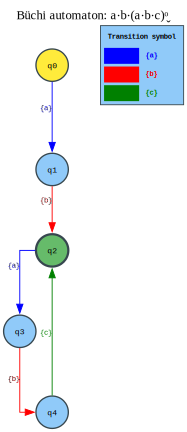

In [2]:
buchi = BuchiAutomaton()
buchi.add_initial_state('q0')
buchi.add_transition('q0', {'a'}, 'q1')
buchi.add_transition('q1', {'b'}, 'q2')
buchi.add_accepting_state('q2')
buchi.add_transition('q2', {'a'}, 'q3')
buchi.add_transition('q3', {'b'}, 'q4')
buchi.add_transition('q4', {'c'}, 'q2')

res = buchi.check_emptiness()
print('witness:', res.witness)

g = draw(buchi, title='Büchi automaton: a·b·(a·b·c)ᵒ̬',
         initial_color='#ffeb3b', accepting_color='#66bb6a',
         edge_colors={'{a}': 'blue', '{b}': 'red', '{c}': 'green'},
         legend_title='Transition symbol')
display.SVG(g.pipe(format='svg'))

## 2. Kripke model

A Kripke model `(S, →, L)` with propositions holding at states.

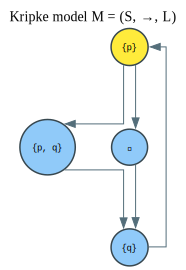

In [3]:
kripke = KripkeModel()
kripke.add_initial_state('s0', {'p'})
kripke.add_state('s1', {'p', 'q'})
kripke.add_state('s2', {'q'})
kripke.add_state('s3', set())

kripke.add_transition('s0', 's1')
kripke.add_transition('s1', 's2')
kripke.add_transition('s2', 's0')
kripke.add_transition('s0', 's3')
kripke.add_transition('s3', 's2')

g = draw(kripke, title='Kripke model M = (S, →, L)',
         node_propositions=kripke.labeling, show_edge_labels=False, use_xlabels=False)
display.SVG(g.pipe(format='svg'))

## 3. Self-loops — infinitely many 'a's

Graphviz renders self-loops beautifully as arcs on the node.

witness: {a}·({a})ω


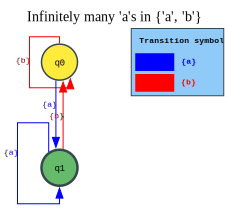

In [4]:
inf_a = BuchiAutomaton()
inf_a.add_initial_state('q0')
inf_a.add_accepting_state('q1')

inf_a.add_transition('q0', {'a'}, 'q1')
inf_a.add_transition('q0', {'b'}, 'q0')  # self-loop
inf_a.add_transition('q1', {'a'}, 'q1')  # self-loop
inf_a.add_transition('q1', {'b'}, 'q0')

res = inf_a.check_emptiness()
print('witness:', res.witness)

g = draw(inf_a, title="Infinitely many 'a's in {'a', 'b'}",
         initial_color='#ffeb3b', accepting_color='#66bb6a',
         edge_colors={'{a}': 'blue', '{b}': 'red'},
         legend_title='Transition symbol')
display.SVG(g.pipe(format='svg'))

## 4. Intersection — both 'a' and 'b' infinitely often

The intersection of two automata: one accepting infinitely many 'a's, another accepting infinitely many 'b's. The product automaton accepts words with *both* 'a' and 'b' infinitely often.

The product state space is `Q₁ × Q₂ × {1, 2}` with a tracking bit that toggles between the two accepting sets. The accepting states are those where bit=1 (watching for `a`).

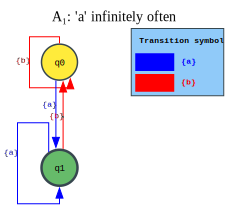

In [5]:
from tutorials.buchi import intersect

def inf_symbol(symbol, other):
    """Automaton accepting 'symbol' infinitely often over alphabet {symbol, other}."""
    a = BuchiAutomaton()
    a.add_initial_state('s0')
    a.add_accepting_state('s1')
    a.add_transition('s0', {symbol}, 's1')
    a.add_transition('s0', {other}, 's0')  # self-loop
    a.add_transition('s1', {symbol}, 's1')  # self-loop (accepting)
    a.add_transition('s1', {other}, 's0')
    return a

a_inf = inf_symbol('a', 'b')      # 'a' infinitely often
b_inf = inf_symbol('b', 'a')      # 'b' infinitely often

g1 = draw(a_inf, title="A₁: 'a' infinitely often",
          initial_color='#ffeb3b', accepting_color='#66bb6a',
          edge_colors={'{a}': 'blue', '{b}': 'red'},
          legend_title='Transition symbol')
display.SVG(g1.pipe(format='svg'))

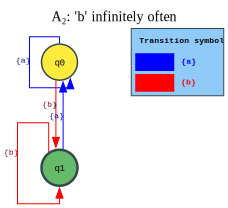

In [6]:
g2 = draw(b_inf, title="A₂: 'b' infinitely often",
          initial_color='#ffeb3b', accepting_color='#66bb6a',
          edge_colors={'{a}': 'blue', '{b}': 'red'},
          legend_title='Transition symbol')
display.SVG(g2.pipe(format='svg'))

Product empty: False
Witness: {a}·({b}{a})ω


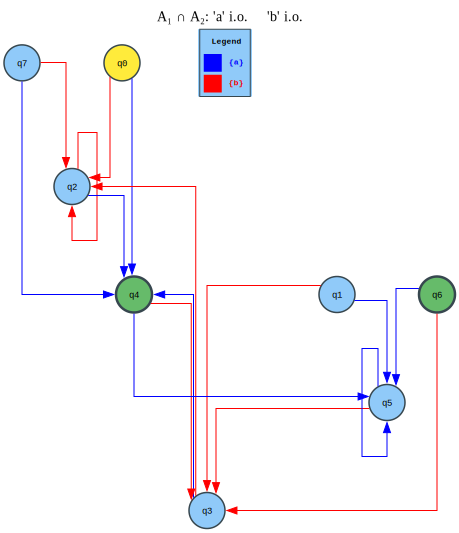

In [7]:
product = intersect(a_inf, b_inf)

res = product.check_emptiness()
print(f'Product empty: {res.is_empty}')
print(f'Witness: {res.witness}')

g = draw(product, title="A₁ ∩ A₂: 'a' i.o. ∧ 'b' i.o.",
         initial_color='#ffeb3b', accepting_color='#66bb6a',
         size='14,10', nodesep=0.8, ranksep=1.0,
         show_edge_labels=False,
         edge_colors={'{a}': 'blue', '{b}': 'red'})
display.SVG(g.pipe(format='svg'))

## 5. Kripke model from a NuPlan lane graph

A **Kripke model** `M = (S, →, L)` is the natural way to represent a road-network graph for temporal reasoning:
- **States** `S` = lane segments and lane connectors near the ego vehicle.
- **Transitions** `→` = the `outgoing_edges` connectivity in the NuPlan map.
- **Labelling** `L` is supplied by a user-defined function `node_to_props(node_id) → set[str]` that inspects each map object and returns the atomic propositions true there.

Propositions used here:

| Proposition | Meaning |
|-------------|---------|
| `lane` | Regular lane segment |
| `connector` | Lane connector (crosses an intersection) |
| `ego` | Ego vehicle's current lane/connector |
| `fork` | More than one outgoing edge (choice point) |

In [8]:
import os, sys
import networkx as nx
from nuplan.common.actor_state.state_representation import Point2D
from nuplan.common.maps.maps_datatypes import SemanticMapLayer
from nuplan.common.maps.nuplan_map.map_factory import NuPlanMapFactory, get_maps_db

_dr_src = os.path.abspath(os.path.join(os.getcwd(), '../../../../driving_ruler_core/src'))
if not os.path.isdir(_dr_src):
    _nb_dir = os.path.dirname(os.path.abspath('visualization_graphviz.ipynb'))
    _dr_src = os.path.abspath(os.path.join(_nb_dir, '../../../../driving_ruler_core/src'))
if _dr_src not in sys.path:
    sys.path.insert(0, _dr_src)

from dr.nuplan_api.data import get_scenarios

# ── Load scenario & map ──────────────────────────────────────────────────────
scenario = get_scenarios(split='mini', scenario_types=['accelerating_at_traffic_light'])[1]
map_factory = NuPlanMapFactory(
    get_maps_db(map_root=scenario.map_root, map_version=scenario.map_version))
nuplan_map = map_factory.build_map_from_name(scenario.map_api.map_name)

ego_state = scenario.get_ego_state_at_iteration(0)
ego_point = Point2D(ego_state.rear_axle.x, ego_state.rear_axle.y)

# ── Build full graph (200 m radius) ─────────────────────────────────────────
direction_layers = [SemanticMapLayer.LANE, SemanticMapLayer.LANE_CONNECTOR]
map_objects = nuplan_map.get_proximal_map_objects(ego_point, 200, direction_layers)

object_map   = {}
object_types = {}
G_full = nx.DiGraph()

for layer in direction_layers:
    for obj in map_objects.get(layer, []):
        try:
            oid  = str(obj.id)
            geom = obj.polygon if hasattr(obj, 'polygon') else obj.geometry
            object_map[oid]   = obj
            object_types[oid] = 'lane' if layer == SemanticMapLayer.LANE else 'connector'
            G_full.add_node(oid, type=object_types[oid])
        except Exception:
            continue

for oid, obj in object_map.items():
    for out in getattr(obj, 'outgoing_edges', []):
        out_id = str(out.id)
        if out_id in G_full:
            G_full.add_edge(oid, out_id)

# ── Identify ego node ────────────────────────────────────────────────────────
ego_obj = (nuplan_map.get_one_map_object(ego_point, SemanticMapLayer.LANE)
           or nuplan_map.get_one_map_object(ego_point, SemanticMapLayer.LANE_CONNECTOR))
ego_id  = str(ego_obj.id) if ego_obj else None

# ── Extract small subgraph via BFS in both directions around ego ─────────────
sub_nodes = set()
if ego_id and ego_id in G_full:
    sub_nodes.update(nx.bfs_tree(G_full, ego_id, depth_limit=10).nodes())

small_G = G_full.subgraph(sub_nodes).copy()
print(f"Subgraph: {small_G.number_of_nodes()} nodes, {small_G.number_of_edges()} edges")
print(f"Ego node: {ego_id}")

Subgraph: 12 nodes, 11 edges
Ego node: 69518


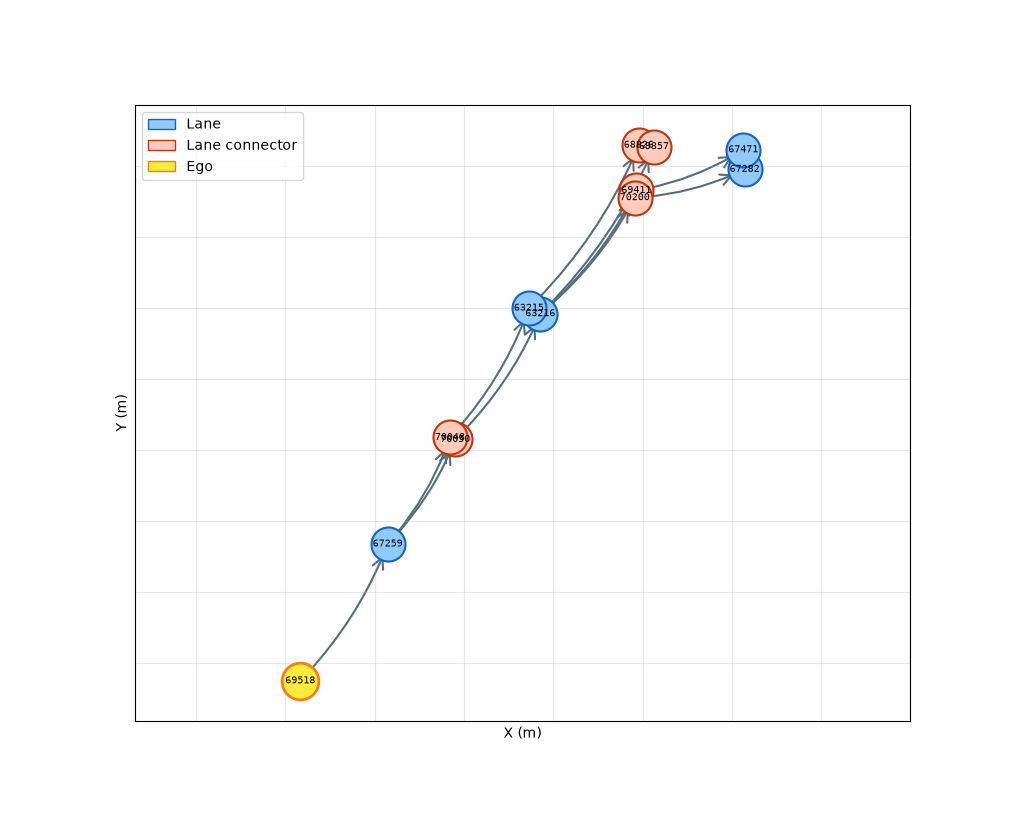

In [9]:
import math
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

pos = {}
for node in small_G.nodes():
    obj = object_map[node]
    geom = obj.polygon if hasattr(obj, 'polygon') else obj.geometry
    c = geom.centroid
    if math.isfinite(c.x) and math.isfinite(c.y):
        pos[node] = (c.x, c.y)

draw_G = small_G.subgraph(pos.keys()).copy()

lane_nodes      = [n for n in draw_G if object_types[n] == 'lane']
connector_nodes = [n for n in draw_G if object_types[n] == 'connector']

fig, ax = plt.subplots(figsize=(10, 8))

nx.draw_networkx_nodes(draw_G, pos, nodelist=lane_nodes,
                       node_color='#90caf9', edgecolors='#1565c0',
                       node_size=600, linewidths=1.5, ax=ax)
nx.draw_networkx_nodes(draw_G, pos, nodelist=connector_nodes,
                       node_color='#ffccbc', edgecolors='#bf360c',
                       node_size=600, linewidths=1.5, ax=ax)
if ego_id and ego_id in draw_G:
    nx.draw_networkx_nodes(draw_G, pos, nodelist=[ego_id],
                           node_color='#ffeb3b', edgecolors='#f57f17',
                           node_size=700, linewidths=2.0, ax=ax)

nx.draw_networkx_edges(draw_G, pos, edge_color='#546e7a', arrows=True,
                       arrowsize=20, arrowstyle='->', width=1.5,
                       connectionstyle='arc3,rad=0.1', ax=ax)
nx.draw_networkx_labels(draw_G, pos, font_size=7, font_family='monospace', ax=ax)

legend = [
    mpatches.Patch(facecolor='#90caf9', edgecolor='#1565c0', label='Lane'),
    mpatches.Patch(facecolor='#ffccbc', edgecolor='#bf360c', label='Lane connector'),
    mpatches.Patch(facecolor='#ffeb3b', edgecolor='#f57f17', label='Ego'),
]
ax.legend(handles=legend, loc='upper left', fontsize=10)
ax.set_title('NuPlan subgraph (NetworkX) — ego neighbourhood', fontsize=13, fontweight='bold')
ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)')

# Set equal-range limits manually to avoid set_aspect NaN/Inf issues
if pos:
    xs = [p[0] for p in pos.values()]
    ys = [p[1] for p in pos.values()]
    xmid, ymid = (min(xs) + max(xs)) / 2, (min(ys) + max(ys)) / 2
    half = max(max(xs) - min(xs), max(ys) - min(ys)) / 2 * 1.15
    ax.set_xlim(xmid - half, xmid + half)
    ax.set_ylim(ymid - half, ymid + half)

ax.grid(True, alpha=0.3)
plt.show()

Kripke model: 12 states, 11 transitions

Propositions per state:
  63215: ['lane']
  63216: ['fork', 'lane']
  67259: ['fork', 'lane']
  67282: ['lane']
  67471: ['lane']
  68826: ['connector']
  69357: ['connector']
  69411: ['connector']
  69518: ['connector', 'ego']  [initial]
  70048: ['connector']
  70050: ['connector']
  70200: ['connector']


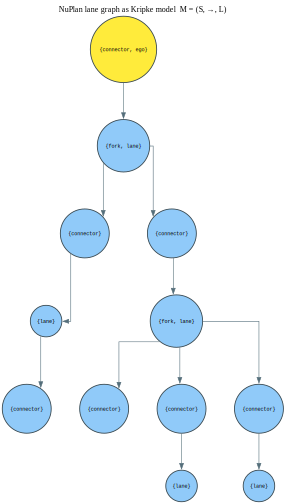

In [10]:
# ── User-defined proposition map ─────────────────────────────────────────────
def node_to_props(node_id: str) -> set:
    """
    Map a NuPlan lane-graph node ID to the atomic propositions holding there.

    This is the user-supplied labelling function L : S → 2^AP for the Kripke model.
    Modify or extend this function to encode any road-level predicates of interest.
    """
    props = set()
    props.add(object_types.get(node_id, 'unknown'))   # 'lane' or 'connector'
    if node_id == ego_id:
        props.add('ego')
    if small_G.out_degree(node_id) > 1:
        props.add('fork')
    return props

# ── Build Kripke model from the NuPlan subgraph ──────────────────────────────
kripke_nuplan = KripkeModel()

for node in small_G.nodes():
    props = node_to_props(node)
    if node == ego_id:
        kripke_nuplan.add_initial_state(node, props)
    else:
        kripke_nuplan.add_state(node, props)

for src, dst in small_G.edges():
    kripke_nuplan.add_transition(src, dst)

print(f"Kripke model: {len(kripke_nuplan.states)} states, "
      f"{sum(len(v) for v in kripke_nuplan._transitions.values())} transitions")
print("\nPropositions per state:")
for s in sorted(kripke_nuplan.states, key=str):
    marker = "  [initial]" if s in kripke_nuplan.initial_states else ""
    print(f"  {s}: {sorted(kripke_nuplan.labeling[s])}{marker}")

# ── Visualize ────────────────────────────────────────────────────────────────
g = draw(kripke_nuplan,
         title='NuPlan lane graph as Kripke model  M = (S, →, L)',
         node_propositions=node_to_props,
         show_edge_labels=False,
         use_xlabels=False,
         initial_color='#ffeb3b',
         size='10,7', nodesep=0.7, ranksep=0.9)
display.SVG(g.pipe(format='svg'))

## 6. LTL → Büchi automata via the Fischer-Ladner closure

The **Fischer-Ladner closure** construction translates an LTL formula `φ` into a Büchi automaton in four steps:

1. **Rewrite** `φ` into the core fragment `{atom, true, ¬, ∧, X, U}` — every other operator (`F`, `G`, `R`, `W`) is syntactic sugar.
2. **Closure** `cl(φ)` — collect every core subformula together with its negation.
3. **Elementary sets** — enumerate the maximal, locally consistent subsets `B ⊆ cl(φ)`.  Each such set becomes a state; consistency enforces the until-expansion law `(φ₁ U φ₂) ≡ φ₂ ∨ (φ₁ ∧ X(φ₁ U φ₂))`.
4. **Transitions** — `B → B'` on letter `σ` if `B ∩ AP = σ` and the `X`/`U` semantics link `B` to `B'`; then degeneralize the resulting GBA to a standard Büchi automaton.

Edge label `{p}` means proposition `p` holds; `∅` means no proposition holds.

F p  →  3 states, 6 edges


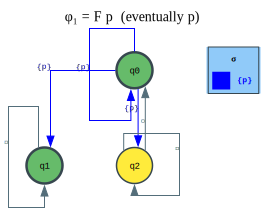

In [11]:
from tutorials.buchi import ltl_to_buchi, Var, F, G, U

# Shared edge-color schemes
COLORS_P    = {'{p}': 'blue'}                                     # single atom
COLORS_PQ   = {'{p}': 'blue', '{q}': 'red', '{p, q}': 'purple'}  # two atoms

# ── φ₁ : F p  ("eventually p") ───────────────────────────────────────────────
phi1 = F(Var('p'))
ba1  = ltl_to_buchi(phi1)
print(f'F p  →  {len(ba1.states)} states, {sum(len(list(ba1.successors(s))) for s in ba1.states)} edges')

g = draw(ba1, title='φ₁ = F p  (eventually p)',
         initial_color='#ffeb3b', accepting_color='#66bb6a',
         edge_colors=COLORS_P, legend_title='σ')
display.SVG(g.pipe(format='svg'))

G p  →  3 states, 6 edges


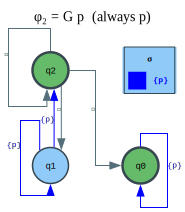

In [12]:
# ── φ₂ : G p  ("always p") ───────────────────────────────────────────────────
phi2 = G(Var('p'))
ba2  = ltl_to_buchi(phi2)
print(f'G p  →  {len(ba2.states)} states, {sum(len(list(ba2.successors(s))) for s in ba2.states)} edges')

g = draw(ba2, title='φ₂ = G p  (always p)',
         initial_color='#ffeb3b', accepting_color='#66bb6a',
         edge_colors=COLORS_P, legend_title='σ')
display.SVG(g.pipe(format='svg'))

p U q  →  5 states, 20 edges


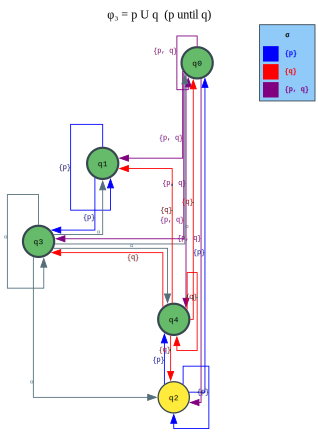

In [13]:
# ── φ₃ : p U q  ("p until q") ────────────────────────────────────────────────
phi3 = U(Var('p'), Var('q'))
ba3  = ltl_to_buchi(phi3)
print(f'p U q  →  {len(ba3.states)} states, {sum(len(list(ba3.successors(s))) for s in ba3.states)} edges')

g = draw(ba3, title='φ₃ = p U q  (p until q)',
         initial_color='#ffeb3b', accepting_color='#66bb6a',
         edge_colors=COLORS_PQ, legend_title='σ')
display.SVG(g.pipe(format='svg'))

G(F p)  →  10 states, 20 edges


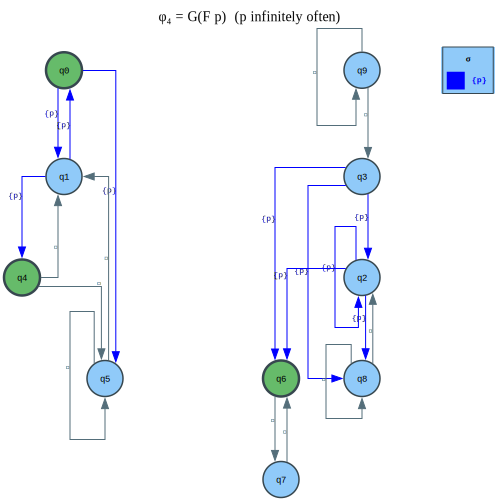

In [14]:
# ── φ₄ : G(F p)  ("p holds infinitely often") ────────────────────────────────
phi4 = G(F(Var('p')))
ba4  = ltl_to_buchi(phi4)
print(f'G(F p)  →  {len(ba4.states)} states, {sum(len(list(ba4.successors(s))) for s in ba4.states)} edges')

g = draw(ba4, title='φ₄ = G(F p)  (p infinitely often)',
         initial_color='#ffeb3b', accepting_color='#66bb6a',
         size='10,7', nodesep=0.6, ranksep=0.9,
         edge_colors=COLORS_P, legend_title='σ')
display.SVG(g.pipe(format='svg'))